In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/player_transfer_value_with_sentiment.csv")

print(df.shape)
df.head()

(5000, 68)


,player_name,season,season_encoded,team,position,position_encoded,current_age,market_value_eur,log_market_value,market_value_tier_encoded,...,transfer_attractiveness_score,vader_positive_score,vader_negative_score,vader_compound_score,tb_polarity,tb_subjectivity,positive_count,negative_count,neutral_count,sentiment_label
0,Lionel Andrés Messi Cuccittini,2019/20,1,Barcelona,Forward,4,25,67500000.0,18.0276,4,...,88.0797,0.1733,0.1283,0.0921,0.1200,0.7767,2,1,0,Positive
1,Antoine Griezmann,2019/20,1,Barcelona,Forward,4,25,37500000.0,17.4399,3,...,81.7368,0.0603,0.1353,-0.1510,0.3083,0.3833,0,2,1,Negative
2,Ousmane Dembélé,2019/20,1,Barcelona,Midfielder,3,25,19500000.0,16.7859,2,...,80.1995,0.1720,0.0853,0.2107,0.2944,0.5167,1,0,2,Positive
3,Anssumane Fati,2019/20,1,Barcelona,Midfielder,3,25,13500000.0,16.4182,2,...,81.6069,0.1080,0.1527,-0.1527,-0.2333,0.0667,1,2,0,Negative
4,Pedro González López,2019/20,1,Barcelona,Defender,2,25,16500000.0,16.6189,2,...,76.7660,0.0613,0.1893,-0.1332,0.2333,0.6593,1,2,0,Negative


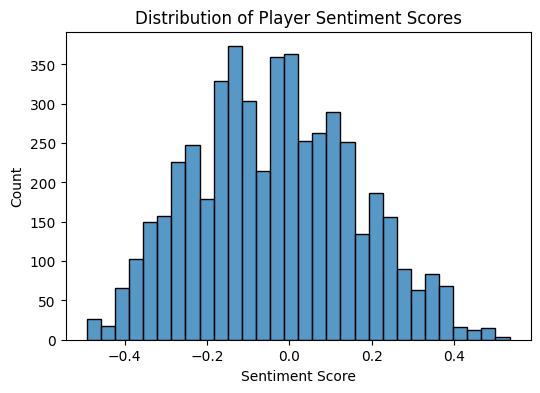

In [3]:
plt.figure(figsize=(6,4))
sns.histplot(df["vader_compound_score"], bins=30)
plt.title("Distribution of Player Sentiment Scores")
plt.xlabel("Sentiment Score")
plt.ylabel("Count")
plt.show()

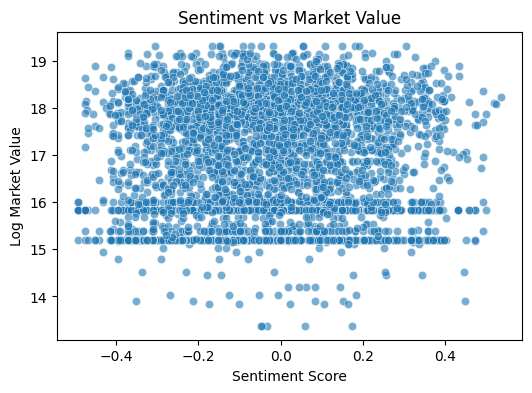

In [4]:
plt.figure(figsize=(6,4))
sns.scatterplot(
    data=df,
    x="vader_compound_score",
    y="log_market_value",
    alpha=0.6
)
plt.title("Sentiment vs Market Value")
plt.xlabel("Sentiment Score")
plt.ylabel("Log Market Value")
plt.show()

In [5]:
top_positive = (
    df.sort_values("vader_compound_score", ascending=False)
    [["player_name", "vader_compound_score", "log_market_value"]]
    .head(10)
    .reset_index(drop=True)
)

top_negative = (
    df.sort_values("vader_compound_score", ascending=True)
    [["player_name", "vader_compound_score", "log_market_value"]]
    .head(10)
    .reset_index(drop=True)
)

print("Top Positive Players")
display(top_positive)

print("\nTop Negative Players")
display(top_negative)

Top Positive Players


,player_name,vader_compound_score,log_market_value
0,Adrien Larsen,0.5351,18.2352
1,Miguel Moreau,0.5223,18.0814
2,Lorenzo Becker,0.5186,18.1001
3,Sergio Escudero Palomo,0.4993,15.8304
4,Declan Brown,0.4993,17.8713
5,Ander Barrenetxea Muguruza,0.4928,15.3841
6,Samuel Chimerenka Chukwueze,0.4928,16.0127
7,Riyad Lopez,0.4928,18.3570
8,Marcus Larsen,0.4909,17.7060
9,Youssef Muller,0.4909,16.9590



Top Negative Players


,player_name,vader_compound_score,log_market_value
0,Tomas Franco Tavares,-0.4919,15.8304
1,Ferland Mendy,-0.4919,15.8304
2,Sergio Ramos García,-0.4919,16.0127
3,Mouctar Diakhaby,-0.4919,16.0127
4,Edgar Badía Guardiola,-0.4919,15.8304
5,Carlos Arturo Bacca Ahumada,-0.4919,15.8304
6,Thibaut Courtois,-0.4919,15.8304
7,Joel Robles Blázquez,-0.4919,15.2018
8,Kevin Cisse,-0.4754,18.6398
9,José María Martín-Bejarano Serrano,-0.4754,15.8304


In [7]:
def player_sentiment_report(player_name):
    player = df[df["player_name"] == player_name]

    if player.empty:
        print("Player not found.")
        return

    row = player.iloc[0]

    score = row["vader_compound_score"]
    market = row["log_market_value"]

    print(f"Player: {row['player_name']}")
    print(f"Position: {row.get('position','N/A')}")
    print(f"Sentiment Score: {score:.3f}")
    print(f"Market Value (log): {market:.3f}")

    if score > 0.2:
        print("Public sentiment: Positive")
    elif score < -0.2:
        print("Public sentiment: Negative")
    else:
        print("Public sentiment: Neutral")

In [8]:
player_sentiment_report("Declan Brown")

Player: Declan Brown
Position: Forward
Sentiment Score: -0.116
Market Value (log): 17.871
Public sentiment: Neutral


In [19]:
def plot_player_sentiment(player_name):
    player = df[df["player_name"] == player_name]

    if player.empty:
        print("Player not found")
        return

    row = player.iloc[0]
    score = row["vader_compound_score"]

    # define color
    color = "green" if score > 0 else "red"

    plt.figure(figsize=(6,2))

    plt.barh(["Player Sentiment"], [score], color=color)

    plt.axvline(0, color="black", linestyle="--")

    plt.xlim(-0.5,0.5)
    plt.text(score, 0, f"{score:.3f}", va='center',
         ha='right' if score < 0 else 'left')

    plt.title(f"Sentiment Score: {player_name}")
    plt.xlabel("Sentiment Score")

    plt.show()

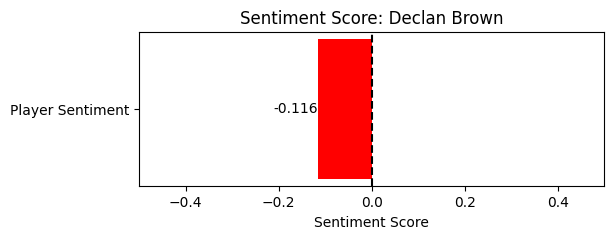

In [20]:
plot_player_sentiment("Declan Brown")